In [3]:
import math, pickle
from pathlib import Path
import numpy as np
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# ----- 1. dummy data -------------------------------------------------------
X_dum, y_dum = make_classification(
    n_samples=20000, n_features=10, n_informative=5,
    weights=[0.9, 0.1], random_state=0,
)
feat = [f"f{i}" for i in range(X_dum.shape[1])]

# ----- 2. train four tree-based models (same depth/size for fair compare) --
dt  = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_dum, y_dum)
rf  = RandomForestClassifier(n_estimators=10, max_depth=4, random_state=0).fit(X_dum, y_dum)
hgb = HistGradientBoostingClassifier(max_iter=10, max_depth=4, random_state=0).fit(X_dum, y_dum)
xgbc = xgb.XGBClassifier(n_estimators=10, max_depth=4,
                         eval_metric="logloss", random_state=0).fit(X_dum, y_dum)

# ----- 3. pickle + size comparison -----------------------------------------
sizes = {}
for name, m in [("dt", dt), ("rf", rf), ("hgb", hgb), ("xgb", xgbc)]:
    p = Path(f"dummy_{name}.pkl")
    with open(p, "wb") as f:
        pickle.dump(m, f)
    sizes[name] = p.stat().st_size

print("Pickle sizes (bytes):")
for k, v in sizes.items():
    print(f"  {k:>4s}: {v:>10,}")

# ----- 4. how each library exposes its trees (the only thing that differs) -
print("\nAPI per library:")
t = dt.tree_
print(f"  DT  : .tree_  arrays   first split feat={feat[t.feature[0]]} "
      f"thr={t.threshold[0]:.3f}  leaves: children_left == -1, value = class counts")
t = rf.estimators_[0].tree_
print(f"  RF  : .estimators_[i].tree_  same arrays as DT, prediction = mean over {len(rf.estimators_)} trees")
n0 = hgb._predictors[0][0].nodes
print(f"  HGB : ._predictors[i][c].nodes  fields={n0.dtype.names[:6]}...  prediction = sigmoid(base + Σ leaf logits)")
xdf = xgbc.get_booster().trees_to_dataframe()
print(f"  XGB : booster.trees_to_dataframe()  cols={list(xdf.columns)}  "
      f"prediction = sigmoid(base + Σ leaf logits)")

# ----- 5. one emit function per library — note the SHAPE is identical -----
def fmt(v):
    v = float(v)
    if math.isnan(v): return "float('nan')"
    if math.isinf(v): return "float('inf')" if v > 0 else "float('-inf')"
    return repr(v)

def emit_sklearn(t, n, d):
    """sklearn DT and RF use the same Tree object."""
    pad = "    " * d
    if t.children_left[n] == -1:                       # leaf
        v = t.value[n][0]
        return f"{pad}return {fmt(v[1] / v.sum())}\n"  # probability
    f = feat[t.feature[n]]
    s  = f"{pad}if x[{f!r}] <= {fmt(t.threshold[n])}:\n"
    s += emit_sklearn(t, t.children_left[n],  d + 1)
    s += f"{pad}else:\n"
    s += emit_sklearn(t, t.children_right[n], d + 1)
    return s

def emit_hgb(nodes, i, d):
    pad = "    " * d
    n = nodes[i]
    if n['is_leaf']:
        return f"{pad}return {fmt(n['value'])}\n"     # logit contribution
    f = feat[n['feature_idx']]; thr = fmt(n['num_threshold'])
    cond = (f"x[{f!r}] != x[{f!r}] or x[{f!r}] <= {thr}"
            if n['missing_go_to_left'] else
            f"x[{f!r}] == x[{f!r}] and x[{f!r}] <= {thr}")
    s  = f"{pad}if {cond}:\n"
    s += emit_hgb(nodes, int(n['left']),  d + 1)
    s += f"{pad}else:\n"
    s += emit_hgb(nodes, int(n['right']), d + 1)
    return s

def emit_xgb(df, n, d):
    row = df[df['Node'] == n].iloc[0]
    pad = "    " * d
    if row['Feature'] == 'Leaf':
        return f"{pad}return {fmt(row['Gain'])}\n"     # logit contribution
    f = row['Feature']; thr = fmt(row['Split'])
    yes = int(row['Yes'].split('-')[1])
    no  = int(row['No'].split('-')[1])
    miss = int(row['Missing'].split('-')[1])
    # XGB uses strict <; NaN goes to Missing (which equals Yes or No)
    nan_left = (miss == yes)
    cond = (f"x[{f!r}] != x[{f!r}] or x[{f!r}] < {thr}"
            if nan_left else
            f"x[{f!r}] == x[{f!r}] and x[{f!r}] < {thr}")
    s  = f"{pad}if {cond}:\n"
    s += emit_xgb(df, yes, d + 1)
    s += f"{pad}else:\n"
    s += emit_xgb(df, no,  d + 1)
    return s

# ----- 6. assemble a full rule-based predictor for each model --------------
def build_dt():
    return "def dt_rule(x):\n" + emit_sklearn(dt.tree_, 0, 1).rstrip("\n")

def build_rf():
    parts = []
    n = len(rf.estimators_)
    for i, est in enumerate(rf.estimators_):
        parts.append(f"def rf_t{i}(x):\n" + emit_sklearn(est.tree_, 0, 1).rstrip("\n"))
    parts.append("def rf_rule(x):")
    parts.append("    return (" + " + ".join(f"rf_t{i}(x)" for i in range(n))
                 + f") / {n}")
    return "\n".join(parts)

def build_hgb():
    parts = [f"HGB_BASE = {fmt(np.ravel(hgb._baseline_prediction)[0])}", "import math"]
    n = 0
    for it, preds in enumerate(hgb._predictors):
        for c, p in enumerate(preds):
            parts.append(f"def hgb_t{it}(x):\n" + emit_hgb(p.nodes, 0, 1).rstrip("\n"))
            n += 1
    parts.append("def hgb_rule(x):")
    parts.append("    s = HGB_BASE")
    parts.extend(f"    s += hgb_t{i}(x)" for i in range(n))
    parts.append("    return 1.0/(1.0+math.exp(-s))")
    return "\n".join(parts)

def build_xgb():
    booster = xgbc.get_booster()
    df = booster.trees_to_dataframe()
    n_trees = int(df['Tree'].max() + 1)
    parts = ["import math"]
    for tid in range(n_trees):
        sub = df[df['Tree'] == tid].reset_index(drop=True)
        parts.append(f"def xgb_t{tid}(x):\n" + emit_xgb(sub, 0, 1).rstrip("\n"))
    # determine base_score empirically from one prediction (robust to XGB version)
    margin0 = booster.predict(xgb.DMatrix(X_dum[:1]), output_margin=True)[0]
    # we need the trees defined to compute their sum — do it after exec, patch later
    parts.append(f"XGB_BASE = None  # patched in after empirical calibration")
    parts.append("def xgb_rule(x):")
    parts.append("    s = XGB_BASE")
    parts.extend(f"    s += xgb_t{i}(x)" for i in range(n_trees))
    parts.append("    return 1.0/(1.0+math.exp(-s))")
    return "\n".join(parts), n_trees, float(margin0)

xgb_code, n_xgb, margin0 = build_xgb()
all_code = "\n\n".join([build_dt(), build_rf(), build_hgb(), xgb_code])
Path("dummy_all_rules.py").write_text(all_code)
print(f"\nGenerated dummy_all_rules.py ({len(all_code):,} chars)")
exec(all_code, globals())

# patch XGB_BASE empirically: margin0 - sum_of_trees_on_row_0
x0 = dict(zip(feat, X_dum[0]))
sum0 = sum(globals()[f"xgb_t{i}"](x0) for i in range(n_xgb))
globals()["XGB_BASE"] = margin0 - sum0

# ----- 7. parity check vs each sklearn/xgb model ---------------------------
print("\nParity check on 2000 rows (max |library − rules|):")
test = X_dum[:2000]
test_dicts = [dict(zip(feat, row)) for row in test]
for name, model, fn in [
    ("DecisionTree", dt,   dt_rule),
    ("RandomForest", rf,   rf_rule),
    ("HistGB",       hgb,  hgb_rule),
    ("XGBoost",      xgbc, xgb_rule),
]:
    sk = model.predict_proba(test)[:, 1]
    rl = np.array([fn(x) for x in test_dicts])
    print(f"  {name:14s}: {np.abs(sk - rl).max():.3e}")

Pickle sizes (bytes):
    dt:      3,625
    rf:     26,477
   hgb:     41,809
   xgb:     21,152

API per library:
  DT  : .tree_  arrays   first split feat=f8 thr=-0.669  leaves: children_left == -1, value = class counts
  RF  : .estimators_[i].tree_  same arrays as DT, prediction = mean over 10 trees
  HGB : ._predictors[i][c].nodes  fields=('value', 'count', 'feature_idx', 'num_threshold', 'missing_go_to_left', 'left')...  prediction = sigmoid(base + Σ leaf logits)
  XGB : booster.trees_to_dataframe()  cols=['Tree', 'Node', 'ID', 'Feature', 'Split', 'Yes', 'No', 'Missing', 'Gain', 'Cover', 'Category']  prediction = sigmoid(base + Σ leaf logits)

Generated dummy_all_rules.py (56,403 chars)

Parity check on 200 rows (max |library − rules|):
  DecisionTree  : 0.000e+00
  RandomForest  : 0.000e+00
  HistGB        : 0.000e+00
  XGBoost       : 6.253e-03


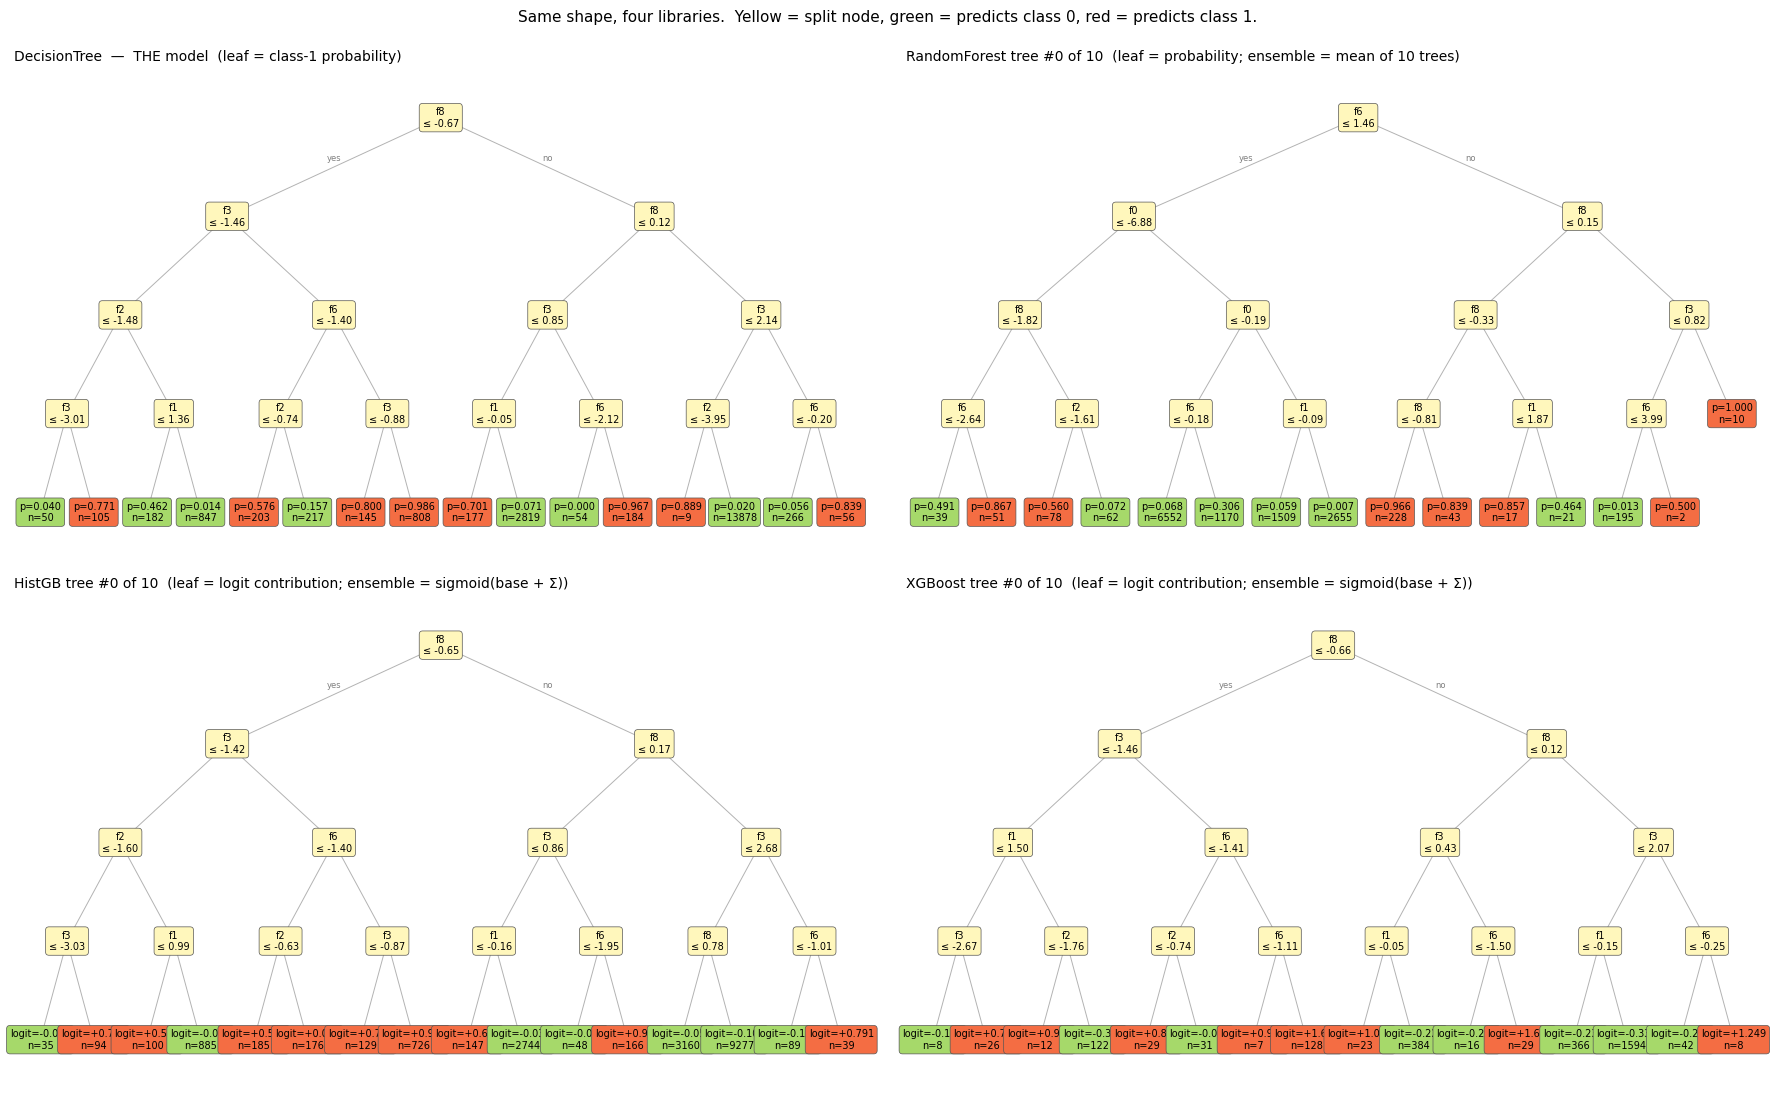

Saved: dummy_trees_visual.png


In [4]:
import matplotlib.pyplot as plt

# ----- per-library extractor -> common node dict --------------------------
# Common schema per node: {is_leaf, left, right, feature, threshold, value,
#                          n_samples, leaf_kind ∈ {'prob','logit'}}

def extract_sklearn(t, feats):
    """sklearn DecisionTree / RandomForest tree_."""
    nodes = {}
    for i in range(t.node_count):
        is_leaf = t.children_left[i] == -1
        if is_leaf:
            v = t.value[i][0]; val = float(v[1] / v.sum())
        else:
            val = None
        nodes[i] = dict(
            is_leaf=is_leaf,
            left=int(t.children_left[i])  if not is_leaf else None,
            right=int(t.children_right[i]) if not is_leaf else None,
            feature=feats[t.feature[i]]   if not is_leaf else None,
            threshold=float(t.threshold[i]) if not is_leaf else None,
            value=val,
            n_samples=int(t.n_node_samples[i]),
            leaf_kind='prob',
        )
    return nodes

def extract_hgb(p_nodes, feats):
    nodes = {}
    for i in range(len(p_nodes)):
        n = p_nodes[i]; is_leaf = bool(n['is_leaf'])
        nodes[i] = dict(
            is_leaf=is_leaf,
            left=int(n['left'])  if not is_leaf else None,
            right=int(n['right']) if not is_leaf else None,
            feature=feats[n['feature_idx']]  if not is_leaf else None,
            threshold=float(n['num_threshold']) if not is_leaf else None,
            value=float(n['value']) if is_leaf else None,
            n_samples=int(n['count']),
            leaf_kind='logit',
        )
    return nodes

def extract_xgb(tdf, feats):
    """tdf must already be filtered to one tree."""
    nodes = {}
    for _, row in tdf.iterrows():
        nid = int(row['Node']); is_leaf = row['Feature'] == 'Leaf'
        nodes[nid] = dict(
            is_leaf=is_leaf,
            left=int(row['Yes'].split('-')[1]) if not is_leaf else None,
            right=int(row['No'].split('-')[1]) if not is_leaf else None,
            feature=row['Feature'] if not is_leaf else None,
            threshold=float(row['Split']) if not is_leaf else None,
            value=float(row['Gain']) if is_leaf else None,
            n_samples=int(row['Cover']),
            leaf_kind='logit',
        )
    return nodes

# ----- layout: leaves left-to-right, internals centered above children -----
def layout(nodes, root=0):
    pos, ctr = {}, [0]
    def walk(nid, depth):
        n = nodes[nid]
        if n['is_leaf']:
            pos[nid] = (ctr[0], -depth); ctr[0] += 1
        else:
            walk(n['left'],  depth + 1)
            walk(n['right'], depth + 1)
            pos[nid] = ((pos[n['left']][0] + pos[n['right']][0]) / 2, -depth)
    walk(root, 0)
    return pos

# ----- one renderer for all four ------------------------------------------
def draw_tree(ax, nodes, title):
    pos = layout(nodes)
    # edges
    for nid, n in nodes.items():
        if not n['is_leaf']:
            x0, y0 = pos[nid]
            for cid, side in [(n['left'], 'yes'), (n['right'], 'no')]:
                x1, y1 = pos[cid]
                ax.plot([x0, x1], [y0, y1], color='gray', lw=0.7, alpha=0.6, zorder=1)
                # label first split's branches for orientation
                if nid == 0:
                    ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.05,
                            side, fontsize=6, color='gray',
                            ha='center', va='bottom', zorder=2)
    # nodes
    for nid, n in nodes.items():
        x, y = pos[nid]
        if n['is_leaf']:
            if n['leaf_kind'] == 'prob':
                txt = f"p={n['value']:.3f}\nn={n['n_samples']}"
                color = '#a6d96a' if n['value'] < 0.5 else '#f46d43'
            else:
                txt = f"logit={n['value']:+.3f}\nn={n['n_samples']}"
                color = '#a6d96a' if n['value'] < 0 else '#f46d43'
            face = color
        else:
            txt = f"{n['feature']}\n≤ {n['threshold']:.2f}"
            face = '#fff7bc'
        ax.text(x, y, txt, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=face,
                          edgecolor='#555', linewidth=0.5), zorder=3)
    ax.set_title(title, fontsize=10, loc='left')
    ax.set_axis_off()
    # a bit of breathing room
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
    ax.set_ylim(min(ys) - 0.5, max(ys) + 0.5)

# ----- render -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

draw_tree(axes[0, 0],
          extract_sklearn(dt.tree_, feat),
          "DecisionTree  —  THE model  (leaf = class-1 probability)")

draw_tree(axes[0, 1],
          extract_sklearn(rf.estimators_[0].tree_, feat),
          "RandomForest tree #0 of 10  (leaf = probability; ensemble = mean of 10 trees)")

draw_tree(axes[1, 0],
          extract_hgb(hgb._predictors[0][0].nodes, feat),
          "HistGB tree #0 of 10  (leaf = logit contribution; ensemble = sigmoid(base + Σ))")

xdf = xgbc.get_booster().trees_to_dataframe()
draw_tree(axes[1, 1],
          extract_xgb(xdf[xdf['Tree'] == 0].reset_index(drop=True), feat),
          "XGBoost tree #0 of 10  (leaf = logit contribution; ensemble = sigmoid(base + Σ))")

fig.suptitle("Same shape, four libraries.  Yellow = split node, green = predicts class 0, "
             "red = predicts class 1.", fontsize=11, y=0.995)
plt.tight_layout()
plt.savefig('dummy_trees_visual.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: dummy_trees_visual.png")

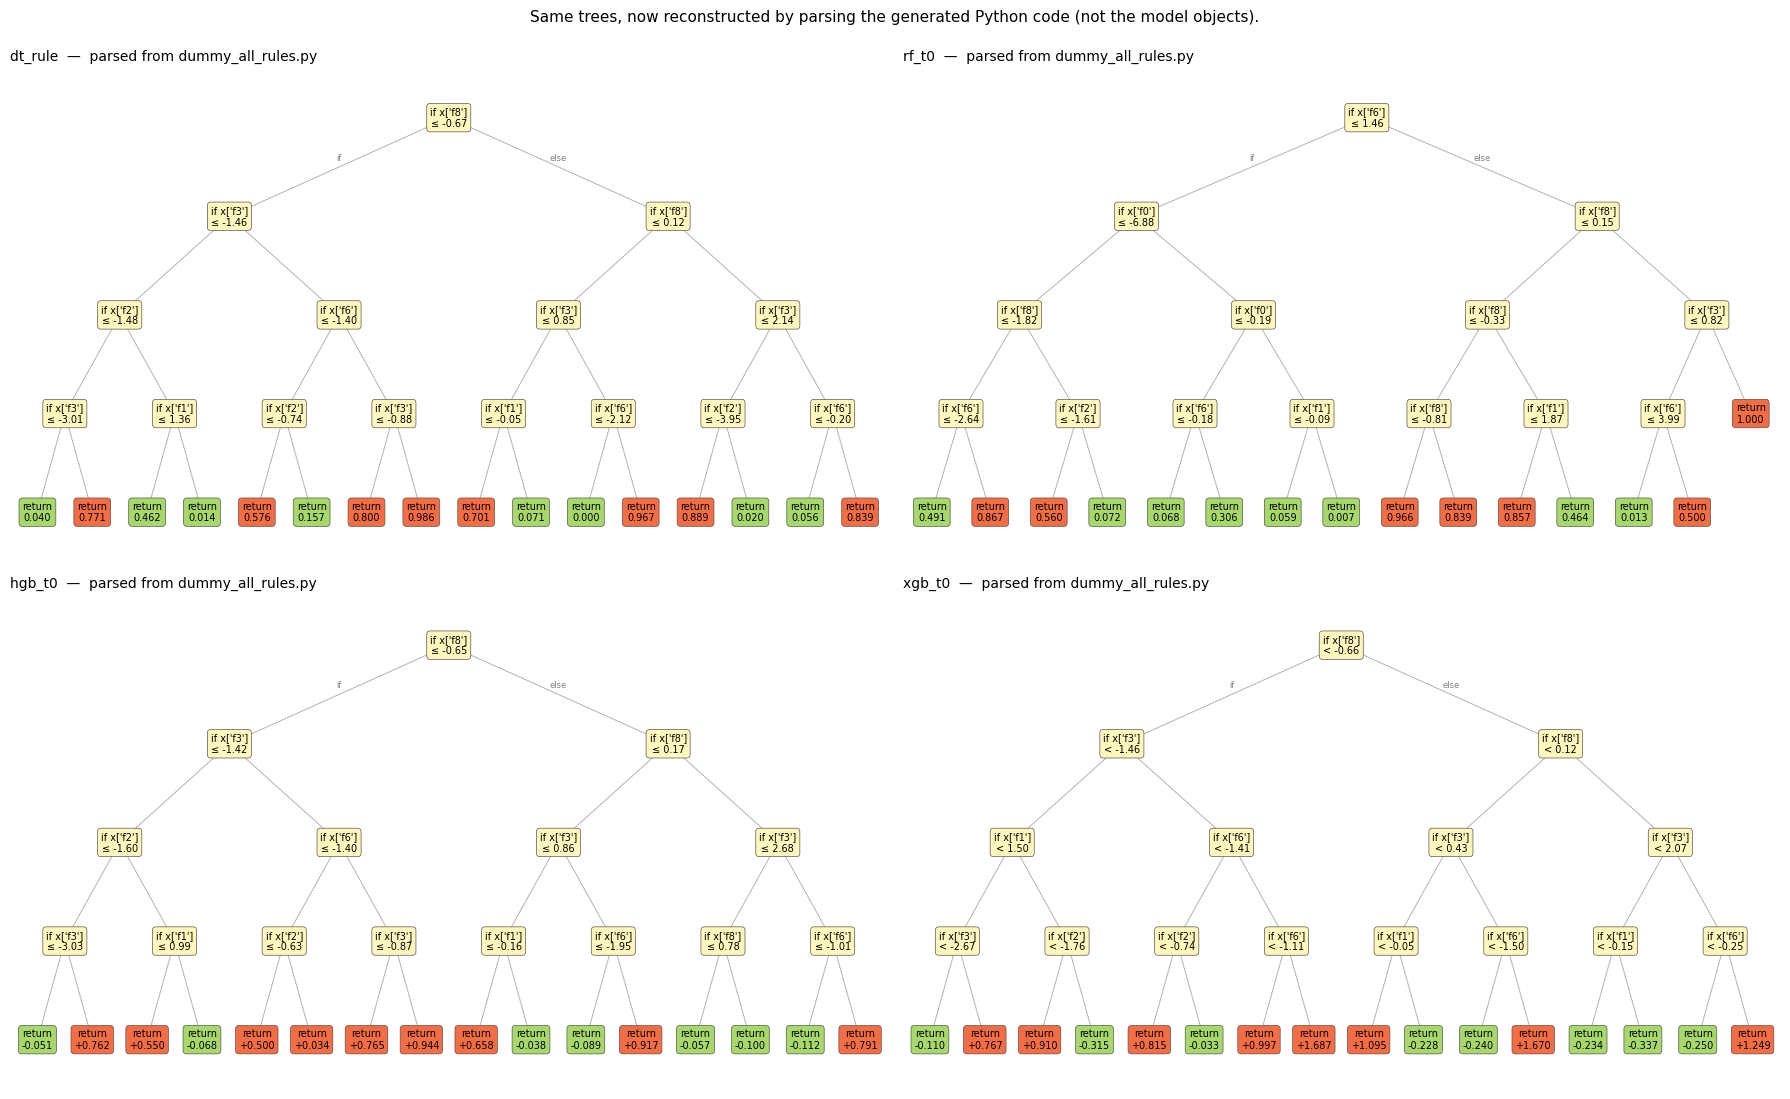

Saved: dummy_trees_from_rules.png


In [5]:
import ast
from pathlib import Path
import matplotlib.pyplot as plt

# ----- read the rules file and grab the function ASTs -------------------
source = Path('dummy_all_rules.py').read_text()
mod = ast.parse(source)
funcs = {n.name: n for n in mod.body if isinstance(n, ast.FunctionDef)}

# ----- evaluator: numbers, unary-minus, and float('inf')/float('nan') ---
def safe_eval(node):
    if isinstance(node, ast.Constant):
        return node.value
    if isinstance(node, ast.UnaryOp) and isinstance(node.op, ast.USub):
        return -safe_eval(node.operand)
    if isinstance(node, ast.Call) and isinstance(node.func, ast.Name) and node.func.id == 'float':
        return float(safe_eval(node.args[0]))
    raise ValueError(f"unexpected literal: {ast.dump(node)}")

# ----- AST walker: rule function body -> shared node-dict schema --------
def extract_from_ast(fn, leaf_kind):
    nodes = {}; ctr = [0]

    def split_info(test):
        # NaN-aware tests are BoolOp(values=[nan-check, comparison]); take the comparison
        comp = test.values[-1] if isinstance(test, ast.BoolOp) else test
        sub = comp.left                                          # x['fXX']
        feat = (sub.slice.value if isinstance(sub.slice, ast.Constant)
                else sub.slice.value.value)                      # Py3.8 fallback
        op_str = '≤' if isinstance(comp.ops[0], ast.LtE) else '<'
        thr = float(safe_eval(comp.comparators[0]))
        return feat, thr, op_str

    def walk(body):
        nid = ctr[0]; ctr[0] += 1
        first = body[0]
        if isinstance(first, ast.Return):
            nodes[nid] = dict(is_leaf=True, left=None, right=None,
                              feature=None, threshold=None, op=None,
                              value=float(safe_eval(first.value)),
                              leaf_kind=leaf_kind)
        else:  # ast.If
            feat, thr, op = split_info(first.test)
            l = walk(first.body); r = walk(first.orelse)
            nodes[nid] = dict(is_leaf=False, left=l, right=r,
                              feature=feat, threshold=thr, op=op,
                              value=None, leaf_kind=None)
        return nid

    walk(fn.body)
    return nodes

# ----- same layout + renderer style as the previous cell ----------------
def layout(nodes, root=0):
    pos, c = {}, [0]
    def walk(nid, d):
        n = nodes[nid]
        if n['is_leaf']:
            pos[nid] = (c[0], -d); c[0] += 1
        else:
            walk(n['left'], d + 1); walk(n['right'], d + 1)
            pos[nid] = ((pos[n['left']][0] + pos[n['right']][0]) / 2, -d)
    walk(root, 0)
    return pos

def draw_rule_tree(ax, nodes, title):
    pos = layout(nodes)
    for nid, n in nodes.items():
        if not n['is_leaf']:
            x0, y0 = pos[nid]
            for cid, side in [(n['left'], 'if'), (n['right'], 'else')]:
                x1, y1 = pos[cid]
                ax.plot([x0, x1], [y0, y1], color='gray', lw=0.7, alpha=0.6, zorder=1)
                if nid == 0:
                    ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.05, side,
                            fontsize=6, color='gray', ha='center', va='bottom', zorder=2)
    for nid, n in nodes.items():
        x, y = pos[nid]
        if n['is_leaf']:
            if n['leaf_kind'] == 'prob':
                txt = f"return\n{n['value']:.3f}"
                face = '#a6d96a' if n['value'] < 0.5 else '#f46d43'
            else:
                txt = f"return\n{n['value']:+.3f}"
                face = '#a6d96a' if n['value'] < 0 else '#f46d43'
        else:
            txt = f"if x[{n['feature']!r}]\n{n['op']} {n['threshold']:.2f}"
            face = '#fff7bc'
        ax.text(x, y, txt, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.35', facecolor=face,
                          edgecolor='#555', linewidth=0.5), zorder=3)
    ax.set_title(title, fontsize=10, loc='left')
    ax.set_axis_off()
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    ax.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
    ax.set_ylim(min(ys) - 0.5, max(ys) + 0.5)

# ----- render the four "first trees" from the rules ---------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

draw_rule_tree(axes[0, 0],
               extract_from_ast(funcs['dt_rule'], 'prob'),
               "dt_rule  —  parsed from dummy_all_rules.py")
draw_rule_tree(axes[0, 1],
               extract_from_ast(funcs['rf_t0'], 'prob'),
               "rf_t0  —  parsed from dummy_all_rules.py")
draw_rule_tree(axes[1, 0],
               extract_from_ast(funcs['hgb_t0'], 'logit'),
               "hgb_t0  —  parsed from dummy_all_rules.py")
draw_rule_tree(axes[1, 1],
               extract_from_ast(funcs['xgb_t0'], 'logit'),
               "xgb_t0  —  parsed from dummy_all_rules.py")

fig.suptitle("Same trees, now reconstructed by parsing the generated Python code "
             "(not the model objects).", fontsize=11, y=0.995)
plt.tight_layout()
plt.savefig('dummy_trees_from_rules.png', dpi=130, bbox_inches='tight')
plt.show()
print("Saved: dummy_trees_from_rules.png")